# Unidad: Redes Neuronales Artificiales
## Perceptrón Multicapa (MLP) — Clasificación con scikit-learn
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

<!-- <img src="https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/notebooks/ml/images/pexels-tara-winstead-8385412.jpg" alt="Red neuronal artificial" width="700"/>

*Foto de [Tara Winstead](https://www.pexels.com/@tara-winstead/) en [Pexels](https://www.pexels.com/)* -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/ann/01_ANN_MLP_Classifier.ipynb)

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Comprender la arquitectura y el funcionamiento de una Red Neuronal Artificial (ANN)  
✅ Implementar un Perceptrón Multicapa (MLP) con `MLPClassifier` de scikit-learn  
✅ Ajustar los hiperparámetros principales: capas, neuronas, función de activación  
✅ Comparar el MLP con un clasificador clásico (Random Forest) usando validación cruzada  

---

## 📖 Marco Teórico

### ¿Qué es una Red Neuronal Artificial?

Una **Red Neuronal Artificial (ANN)** es un modelo computacional inspirado en el cerebro biológico. Está formada por nodos (*neuronas*) organizados en **capas** que se conectan entre sí mediante pesos ajustables.

```
Entrada  →  Capa Oculta 1  →  Capa Oculta 2  →  Salida
 x₁ ──┐                                        ┌── ŷ₁
 x₂ ──┼──  [ n₁, n₂, ... ]  [ n₁, n₂, ... ] ──┼── ŷ₂
 x₃ ──┘                                        └── ŷ₃
```

### Perceptrón Multicapa (MLP)

El **MLP** (*Multilayer Perceptron*) es la arquitectura más básica de red neuronal profunda. Cada neurona calcula:

$$z = \sum_{i} w_i x_i + b$$

$$a = f(z)$$

donde $f$ es la **función de activación** y $b$ el sesgo (*bias*).

### Funciones de activación

| Función | Fórmula | Rango | Uso típico |
|---------|---------|-------|------------|
| ReLU | $\max(0, z)$ | $[0, \infty)$ | Capas ocultas (por defecto) |
| Sigmoid | $\frac{1}{1+e^{-z}}$ | $(0, 1)$ | Salida binaria |
| Tanh | $\tanh(z)$ | $(-1, 1)$ | Capas ocultas |
| Softmax | $\frac{e^{z_i}}{\sum e^{z_j}}$ | $(0, 1)$ | Salida multiclase |

### Backpropagation y descenso de gradiente

El entrenamiento ajusta los pesos minimizando la **función de pérdida** $\mathcal{L}$ mediante el algoritmo de **retropropagación**:

$$w \leftarrow w - \eta \frac{\partial \mathcal{L}}{\partial w}$$

donde $\eta$ es la **tasa de aprendizaje** (*learning rate*).

> 📌 **Clave**: El MLP aprende representaciones jerárquicas de los datos. Cada capa aprende características progresivamente más abstractas.

### MLPClassifier en scikit-learn

Los parámetros más importantes:

| Parámetro | Descripción | Valor por defecto |
|-----------|-------------|-------------------|
| `hidden_layer_sizes` | Tupla con el número de neuronas por capa | `(100,)` |
| `activation` | Función de activación: `relu`, `tanh`, `logistic` | `relu` |
| `solver` | Optimizador: `adam`, `sgd`, `lbfgs` | `adam` |
| `max_iter` | Iteraciones máximas | `200` |
| `random_state` | Semilla de aleatoriedad | `None` |

## 📦 Paso 1: Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

SEED = 42
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🌸 Paso 2: Dataset — Iris

Usamos el clásico dataset **Iris** (150 muestras, 4 features, 3 clases).  
Es ideal para explorar clasificadores multiclase.

> 💡 El dataset ya está integrado en scikit-learn, no requiere descarga externa.

In [3]:
# Cargar dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
class_names = iris.target_names

print(f"📊 Shape: {X.shape}")
print(f"📊 Clases: {list(class_names)}")
print(f"📊 Distribución:\n{pd.Series(y).value_counts().rename(index=dict(enumerate(class_names)))}")
X.describe().round(2)

📊 Shape: (150, 4)
📊 Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
📊 Distribución:
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## ✂️ Paso 3: División train/test y escalado

> ⚠️ **Importante**: el MLP usa distancias euclídeas internamente. **Siempre escalar** las features antes de entrenar.  
> Usamos `Pipeline` para evitar *data leakage* al hacer cross-validation.

In [6]:
# División train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"📊 Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# Pipelines: StandardScaler + modelo (evita data leakage en CV)
pipe_mlp = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        random_state=SEED,
        max_iter=500
    ))
])

pipe_rf = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=SEED))
])

print("✅ Pipelines creados")

📊 Train: 120 muestras | Test: 30 muestras
✅ Pipelines creados


## 🧠 Paso 4: Entrenamiento y evaluación en test

Entrenamos ambos modelos y comparamos sus métricas sobre el conjunto de test.

In [8]:
# Entrenamiento
pipe_mlp.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Predicciones
y_pred_mlp = pipe_mlp.predict(X_test)
y_pred_rf  = pipe_rf.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"🧠 MLP Accuracy (test):          {acc_mlp:.4f}")
print(f"🌲 Random Forest Accuracy (test): {acc_rf:.4f}")
print()

# Pérdida final del MLP
mlp_model = pipe_mlp.named_steps['mlp']
print(f"💡 MLP — pérdida final: {mlp_model.loss_:.6f}")
print(f"💡 MLP — mejor pérdida: {mlp_model.best_loss_:.6f}")
print(f"💡 MLP — iteraciones:   {mlp_model.n_iter_}")

🧠 MLP Accuracy (test):          0.9667
🌲 Random Forest Accuracy (test): 0.9000

💡 MLP — pérdida final: 0.002128
💡 MLP — mejor pérdida: 0.002128
💡 MLP — iteraciones:   180


## 📊 Paso 5: Matrices de confusión comparativas

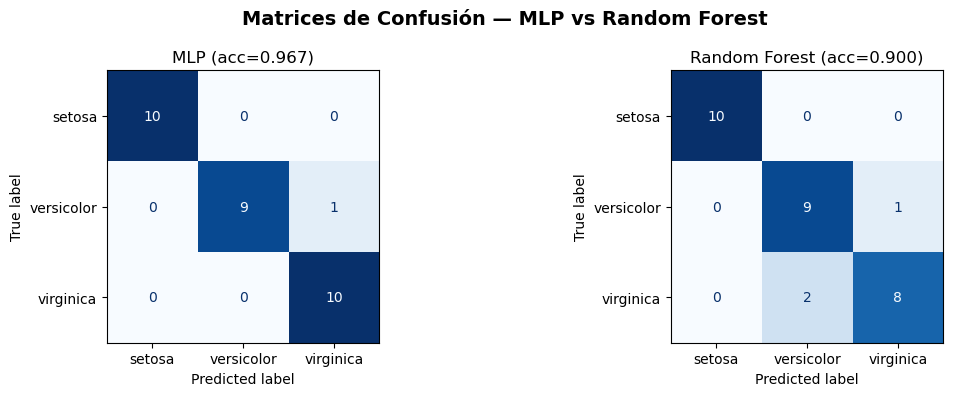

In [9]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Matrices de Confusión — MLP vs Random Forest", fontsize=14, fontweight='bold')

for ax, y_pred, title in zip(axes,
                              [y_pred_mlp, y_pred_rf],
                              [f'MLP (acc={acc_mlp:.3f})', f'Random Forest (acc={acc_rf:.3f})']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.grid(False)

plt.tight_layout()
plt.show()

## 📋 Paso 6: Reporte de clasificación

In [10]:
print("=" * 50)
print("🧠 MLP — Reporte de Clasificación")
print("=" * 50)
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

print("=" * 50)
print("🌲 Random Forest — Reporte de Clasificación")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

🧠 MLP — Reporte de Clasificación
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

🌲 Random Forest — Reporte de Clasificación
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 🔁 Paso 7: Validación cruzada (Cross-Validation)

Para una estimación más robusta usamos **5-Fold Stratified Cross-Validation**.

> 💡 Los `Pipeline` garantizan que el escalado se ajusta solo sobre los datos de entrenamiento de cada fold.

🧠 MLP          — CV accuracy: 0.9467 ± 0.0542
🌲 Random Forest — CV accuracy: 0.9467  ± 0.0267


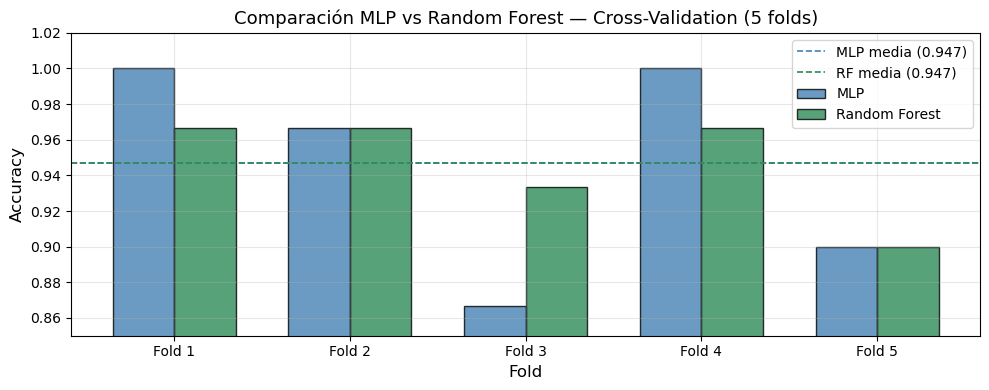

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scores_mlp = cross_val_score(pipe_mlp, X, y, cv=cv, scoring='accuracy')
scores_rf  = cross_val_score(pipe_rf,  X, y, cv=cv, scoring='accuracy')

print(f"🧠 MLP          — CV accuracy: {scores_mlp.mean():.4f} ± {scores_mlp.std():.4f}")
print(f"🌲 Random Forest — CV accuracy: {scores_rf.mean():.4f}  ± {scores_rf.std():.4f}")

# Visualización comparativa de scores por fold
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, 6)
width = 0.35

bars1 = ax.bar(x - width/2, scores_mlp, width, label='MLP', color='steelblue',
               edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, scores_rf,  width, label='Random Forest', color='seagreen',
               edgecolor='black', alpha=0.8)

ax.axhline(scores_mlp.mean(), color='steelblue', linestyle='--', linewidth=1.2,
           label=f'MLP media ({scores_mlp.mean():.3f})')
ax.axhline(scores_rf.mean(),  color='seagreen',  linestyle='--', linewidth=1.2,
           label=f'RF media ({scores_rf.mean():.3f})')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación MLP vs Random Forest — Cross-Validation (5 folds)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 📉 Paso 8: Curva de pérdida del MLP

Visualizamos cómo evoluciona la **loss** durante el entrenamiento, útil para detectar si el modelo convergió correctamente.

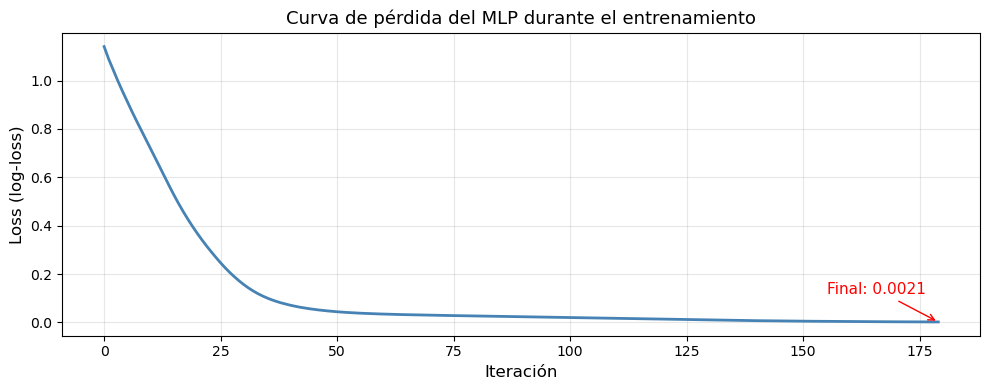

💡 Convergió en 180 iteraciones


In [13]:
# Reentrenamos el MLP con verbose=False para obtener la curva de pérdida
mlp_loss = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    random_state=SEED,
    max_iter=500
)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
mlp_loss.fit(X_train_sc, y_train)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_loss.loss_curve_, color='steelblue', linewidth=2)
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('Loss (log-loss)', fontsize=12)
ax.set_title('Curva de pérdida del MLP durante el entrenamiento', fontsize=13)
ax.grid(True, alpha=0.3)
ax.annotate(f'Final: {mlp_loss.loss_:.4f}',
            xy=(len(mlp_loss.loss_curve_)-1, mlp_loss.loss_curve_[-1]),
            xytext=(-80, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=11)
plt.tight_layout()
plt.show()

print(f"💡 Convergió en {mlp_loss.n_iter_} iteraciones")

## 🎓 Resumen y Conclusiones

### Mini resumen tipo clase

| Concepto | Clave |
|---|---|
| Neurona | Combina entradas con pesos, aplica función de activación |
| Capa oculta | Aprende representaciones intermedias de los datos |
| ReLU | Función de activación más común: $\max(0, z)$ |
| Backpropagation | Algoritmo para ajustar pesos minimizando la pérdida |
| StandardScaler | **Obligatorio** antes del MLP — sensible a la escala |
| Pipeline | Evita data leakage al combinar scaler + modelo en CV |
| `hidden_layer_sizes` | Tupla: cada valor = neuronas en esa capa oculta |

### ⚠️ Errores comunes

| Error | Problema | Solución |
|---|---|---|
| ❌ Entrenar sin escalar | MLP converge mal o no converge | Usar `StandardScaler` siempre |
| ❌ Escalar fuera del Pipeline | Data leakage en cross-validation | Encapsular scaler en `Pipeline` |
| ❌ `max_iter` muy bajo | El modelo no converge | Aumentar `max_iter` o revisar `loss_curve_` |
| ❌ Red muy grande en dataset chico | Sobreajuste | Reducir capas/neuronas, usar regularización |

### 🚀 ¿Qué sigue?

- 🔗 Redes neuronales profundas con **Keras/TensorFlow**
- 🔗 Ajuste de hiperparámetros del MLP con **GridSearchCV**
- 🔗 Regularización: **dropout**, **early stopping**

> 📚 **Referencias:**
> - [MLPClassifier — scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
> - [Neural Networks — scikit-learn User Guide](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)

---
<br>

**Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER**

Este notebook está licenciado bajo [Creative Commons BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
Podés compartirlo y adaptarlo con atribución y bajo la misma licencia.

*Cristian Pacifico — FCAD/UNER*